In [35]:
!pip install pandas
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124

Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2020/avx512, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo/avx512, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2020/avx2, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo/avx2, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2020/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic
Looking in indexes: https://download.pytorch.org/whl/cu124
Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2020/avx512, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo/avx512, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2020/avx2, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo/avx2, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2020/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo/gene

In [36]:
import subprocess
print(subprocess.run(["hostname"], capture_output=True, text=True).stdout)
print(subprocess.run(["nvidia-smi"], capture_output=True, text=True).stdout)
print(subprocess.run(["nvidia-smi"], capture_output=True, text=True).stderr)

fc10420

Wed Jul  1 09:26:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.03             Driver Version: 580.159.03     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 80GB HBM3          On  |   00000000:0C:00.0 Off |                    0 |
| N/A   22C    P0             66W /  700W |       0MiB /  81559MiB |      0%      Default |
|                                         |                        |             Disabled |
+--------------------------------------

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import socket
print(socket.gethostname())
import torch
from torch import nn
from torch.utils.data import TensorDataset,DataLoader, Dataset
print("cuda available?", torch.cuda.is_available())
print(torch.version.cuda)
import scipy.linalg as linalg
import matplotlib.pyplot as plt
print(f"NumPy:  {np.__version__}")
print(f"PyTorch: {torch.__version__}")
import os
device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")
#test = np.empty(2)
#np.save('/home/dtian/scratch/Di_Research/CNN_Weights/test.npy', test)

fc10420
cuda available? False
12.4
NumPy:  1.25.2
PyTorch: 2.6.0+cu124
Using cpu device


In [38]:
os.environ.get("SLURM_JOB_ID")
import os, subprocess
print("JOB_ID          =", os.environ.get("SLURM_JOB_ID"))
print("CUDA_VISIBLE     =", repr(os.environ.get("CUDA_VISIBLE_DEVICES")))
print("SLURM_JOB_GPUS   =", os.environ.get("SLURM_JOB_GPUS"))
print("SLURM_GPUS_PER_NODE =", os.environ.get("SLURM_GPUS_PER_NODE"))
print(subprocess.run(["scontrol","show","job",os.environ["SLURM_JOB_ID"]],
                     capture_output=True, text=True).stdout)

JOB_ID          = 46476032
CUDA_VISIBLE     = '0'
SLURM_JOB_GPUS   = 1
SLURM_GPUS_PER_NODE = h100:1
JobId=46476032 JobName=start_local_job
   UserId=dtian(3160549) GroupId=dtian(3160549) MCS_label=N/A
   Priority=2367202 Nice=0 Account=rrg-acliu_gpu QOS=normal
   JobState=RUNNING Reason=None Dependency=(null)
   Requeue=0 Restarts=0 BatchFlag=1 Reboot=0 ExitCode=0:0
   RunTime=13:24:37 TimeLimit=1-06:00:00 TimeMin=N/A
   SubmitTime=2026-06-30T20:01:48 EligibleTime=2026-06-30T20:01:48
   AccrueTime=2026-06-30T20:01:48
   StartTime=2026-06-30T20:01:59 EndTime=2026-07-02T02:01:59 Deadline=N/A
   SuspendTime=None SecsPreSuspend=0 LastSchedEval=2026-06-30T20:01:59 Scheduler=Main
   Partition=gpubase_bygpu_b4 AllocNode:Sid=login1:918811
   ReqNodeList=(null) ExcNodeList=(null)
   NodeList=fc10420
   BatchHost=fc10420
   NumNodes=1 NumCPUs=12 NumTasks=1 CPUs/Task=12 ReqB:S:C:T=0:0:*:*
   ReqTRES=cpu=12,mem=512G,node=1,billing=21688,gres/gpu=1,gres/gpu:h100=1
   AllocTRES=cpu=12,mem=512G,node=

In [39]:
import torch
try:
    torch.cuda.init()
    print("OK, device count =", torch.cuda.device_count())
    print(torch.cuda.get_device_name(0))
except Exception as e:
    print("REAL ERROR:", repr(e))

REAL ERROR: RuntimeError('CUDA driver initialization failed, you might not have a CUDA gpu.')


In [40]:
import socket, os
print("kernel hostname :", socket.gethostname())
print("job id          :", os.environ.get("SLURM_JOB_ID"))

kernel hostname : fc10420
job id          : 46476032


In [41]:
trans_scin_range = (0.01,0.2)
AGN_scin_range = (0.00005,0.2)  ## replicates the observed variability fractions in CHILES VERDES
varbins = np.array([0,0.02,0.1]) ## fractional brightness fluctuation standard deviation. 0.1 Corresponds to a 10% RMS flux density fluctuation
varprobs = np.array([136/185,33/185,16/185]) ## correspond probabilities. Must sum to 1

### LOAD IN THE VARIABILITY: ###

#scinlib = np.load('/Users/dtian/Documents/Programming/Di_Research/Di_codefromFir/scintillation_library.npz')['varlib']
scinlib = np.load('/home/dtian/scratch/Di_Research/Di_codefromFir/scintillation_library.npz')['varlib']
#varlib = np.load('/Users/dtian/Documents/Programming/Di_Research/Di_codefromFir/variation_library.npz')['varlib']
varlib = np.load('/home/dtian/scratch/Di_Research/Di_codefromFir/variation_library.npz')['varlib']

In [42]:
#transientsdata = (np.load('/Users/dtian/Documents/Programming/Di_Research/Di_codefromFir/TDE_afterglows/ISM_profile/JettedTDE_ISM1.npz')['data'])[:,:,20]
transientsdata = (np.load('/home/dtian/scratch/Di_Research/Di_codefromFir/TDE_afterglows/ISM_profile/JettedTDE_ISM1.npz')['data'])[:,:,20]
print(transientsdata.shape) 

(7000, 608)


In [43]:
def make_gaussian_heatmap(binary_target, sigma=2.0):
    """
    binary_target: (H, W) array with a few 1s at feature locations.
    returns:       (H, W) float heatmap, peaks = 1.0 at each feature.
    """
    H, W = binary_target.shape
    heatmap = np.zeros((H, W), dtype=np.float32)

    # locations of the 1s
    ys, xs = np.nonzero(binary_target)

    # precompute kernel radius (3 sigma covers ~99% of the blob)
    radius = int(np.ceil(3 * sigma))

    for cy, cx in zip(ys, xs):
        # bounds of the patch to write into (clipped to image edges)
        y0, y1 = max(0, cy - radius), min(H, cy + radius + 1)
        x0, x1 = max(0, cx - radius), min(W, cx + radius + 1)

        yy, xx = np.mgrid[y0:y1, x0:x1]
        g = np.exp(-((yy - cy) ** 2 + (xx - cx) ** 2) / (2 * sigma ** 2))

        # max-combine so overlapping blobs stay <= 1
        heatmap[y0:y1, x0:x1] = np.maximum(heatmap[y0:y1, x0:x1], g)

    return heatmap

In [44]:
def gaussian2d(x,y,meanx,meany):

    FWHM = 5

    '''
    returns a 2d gaussian with the right shape
    '''

    return np.exp(-0.5*2.3**2*((x-meanx)**2+(y-meany)**2)/FWHM**2) # factor of 2.3 converts the FWHM to a standard deviation

def genbackground(xlen,ylen,tlen,Nbgnd,noiseamp=0.1):

    x = np.arange(xlen) ## x,y,t arrays
    y = np.arange(ylen)
    t = np.arange(tlen) 

    xx,yy,tt = np.meshgrid(x,y,t) ## create a grid of x,y positions to evaluate at

    #np.random.seed(41)
    rng = np.random.default_rng(123)
    
    noisefield = noiseamp*rng.standard_normal(size = (xlen,ylen,tlen)) # generate the noise

    backgroundfield = np.zeros(noisefield.shape) ## array for the transient layer to be created in
    
    x0 = [] ## these record the x, y, and time mean values for each transient signal
    y0 = [] ## these record the x, y, and time mean values for each transient signal
    positions = np.zeros((Nbgnd,2))

    for i in range(Nbgnd): ## for each background source

        x0.append(np.random.randint(xlen))
        y0.append(np.random.randint(ylen)) ## generate a uniform random map position

        bgfluxdensity = 10**(2*np.random.rand()-1) ## brightness, right now log-uniform between 0.1 and 10

        layer = bgfluxdensity*gaussian2d(xx,yy,x0[-1],y0[-1]) # add the map layer value

        ## apply intrinsic variability:

        idx = np.random.randint(2000)
        phase = np.random.randint(608)

        randfloat = np.random.rand()
        
        if randfloat <= varprobs[0]:
            amp = varbins[0]
        elif randfloat <= varprobs[0]+varprobs[1]:
            amp = varbins[1]
        else:
            amp = varbins[2]
        
        layer*= 1+amp*(varlib[idx][phase:])[np.newaxis,np.newaxis,:tlen]

        ## apply extrinsic variability:

        idx = np.random.randint(2000)
        phase = np.random.randint(608)
        amp = 10**((np.log10(AGN_scin_range[1]/AGN_scin_range[0]))*np.random.rand()+np.log10(AGN_scin_range[0]))
        #print(amp)

        layer*= 1+amp*(varlib[idx][phase:])[np.newaxis,np.newaxis,:tlen]

        backgroundfield += layer



    positions[:,0] = np.array(x0)
    positions[:,1] = np.array(y0)

    return backgroundfield,noisefield,positions
        
def gentransients(xlen,ylen,tlen,Ntrans):
    '''
    Return  transient_field:    100*100*608 transient field
            positions:          Ntrans * 2 transient positions
            gaussian_transient_map 100*100 2d-gaussian position of the transient
    '''

    global transientsdata
    #np.random.seed(41)
    x = np.arange(xlen) ## x and y arrays
    y = np.arange(ylen)
    t = np.arange(tlen) 

    xx,yy,tt = np.meshgrid(x,y,t) ## create a grid of x,y positions to evaluate at

    transient_field = np.zeros((xlen,ylen,tlen)) ## array for the transient layer to be created in
    
    x0 = [] ## these record the x, y, and time mean values for each transient signal
    y0 = [] ## these record the x, y, and time mean values for each transient signal
    positions = np.zeros((Ntrans,2))
    transient_map = np.zeros((xlen, ylen))

    for i in range(Ntrans):

        x0.append(np.random.randint(xlen))
        y0.append(np.random.randint(ylen))

        while True:
            LCidx = np.random.randint(7000)
            LC = transientsdata[LCidx]
            if np.max(LC) != 0: break #This ensure np.max is no zero and eliminate Nan
        LC /= np.max(LC)
        transfluxdensity = 10**(np.random.rand()-0.5) ## right now log-uniform between 0.3 and 3 ## change as you see fit

        ## apply the shape of the lightcurve
        
        layer = transfluxdensity*gaussian2d(xx,yy,x0[-1],y0[-1])*LC[np.newaxis,np.newaxis,:tlen]

        ## apply extrinsic variability:

        idx = np.random.randint(2000)
        phase = np.random.randint(608)
        amp = 10**((np.log10(trans_scin_range[1]/trans_scin_range[0]))*np.random.rand()+np.log10(trans_scin_range[0]))
        #print(amp)

        layer*= 1+amp*(varlib[idx][phase:])[np.newaxis,np.newaxis,:tlen]

        transient_field += layer

        transient_map[y0[-1]][x0[-1]] = 1
    gaussian_transient_map = make_gaussian_heatmap(transient_map)
    positions[:,0] = np.array(x0)
    positions[:,1] = np.array(y0)

    return transient_field,positions,gaussian_transient_map


In [45]:
bg,noise,bgpositions = genbackground(100,100,608,np.random.randint(5, 20),noiseamp = 0.1)
#bg: intrinsic and extrinsic, noise: random, bgpositions: 

In [46]:
transients,transientspositions, target_map = gentransients(100,100,608,np.random.randint(10))

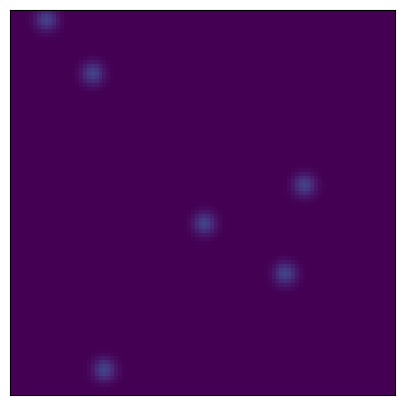

In [47]:
'''
Show the target map, where transient is 1 and rest is 0
'''
plt.figure(figsize = (5,5))
plt.imshow((target_map),vmax = 5,vmin = 0)
plt.xticks([])
plt.yticks([])
plt.show()
plt.close()

In [48]:
# generates and saves animation frames for the above generated field
for frame in range(100):
    plt.figure(figsize = (5,5))
    plt.imshow((bg+noise+transients)[:,:,6*frame],vmax = 5,vmin = 0)
    plt.xticks([])
    plt.yticks([])
    #plt.savefig('/Users/dtian/Documents/Programming/Di_Research/example_animation/frame_%d.png' %frame)
    #plt.show()
    plt.close()

In [49]:
''''
def genfields(Nfields=10, xlen=100, ylen=100, tlen=608, Nbgnd=15 ,noiseamp=0.1, Ntrans=2):
    combined_fields = []
    backgrounds = []
    noises = []
    transients = []
    bgpositions = []
    transientspositions = []
    gaussian_transient_maps = []
    index = 0
    for field in range(Nfields):
        print("Generating Image Index:", index)
        index = index + 1
        Nbgnd = np.random.randint(5, 20) #Number of background is from 5 to 19
        Ntrans = np.random.randint(10) #Number of Ntrans is from 0 to 10
        bg,noise,bgposition = genbackground(xlen,ylen,tlen,Nbgnd,noiseamp)
        transient_field,transientsposition,gaussian_transient_map = gentransients(xlen,ylen,tlen,Ntrans)
        combined_fields.append(bg+noise+transient_field)
        backgrounds.append(bg)
        noises.append(noise)
        transients.append(transient_field)
        bgpositions.append(bgposition)
        transientspositions.append(transientsposition)
        gaussian_transient_maps.append(gaussian_transient_map)
    combined_fields = np.array(combined_fields)
    backgrounds = np.array(backgrounds)
    noises = np.array(noises)
    transients = np.array(transients)
    #bgpositions = np.array(bgpositions)
    #transientspositions = np.array(transientspositions)
    target_maps = np.array(target_maps)
    return combined_fields, backgrounds, noises, transients, bgpositions, transientspositions, gaussian_transient_maps
'''

'\'\ndef genfields(Nfields=10, xlen=100, ylen=100, tlen=608, Nbgnd=15 ,noiseamp=0.1, Ntrans=2):\n    combined_fields = []\n    backgrounds = []\n    noises = []\n    transients = []\n    bgpositions = []\n    transientspositions = []\n    gaussian_transient_maps = []\n    index = 0\n    for field in range(Nfields):\n        print("Generating Image Index:", index)\n        index = index + 1\n        Nbgnd = np.random.randint(5, 20) #Number of background is from 5 to 19\n        Ntrans = np.random.randint(10) #Number of Ntrans is from 0 to 10\n        bg,noise,bgposition = genbackground(xlen,ylen,tlen,Nbgnd,noiseamp)\n        transient_field,transientsposition,gaussian_transient_map = gentransients(xlen,ylen,tlen,Ntrans)\n        combined_fields.append(bg+noise+transient_field)\n        backgrounds.append(bg)\n        noises.append(noise)\n        transients.append(transient_field)\n        bgpositions.append(bgposition)\n        transientspositions.append(transientsposition)\n        ga

In [50]:

def genfields(Nfields=10, xlen=100, ylen=100, tlen=608, noiseamp=0.1, transient_toggle = True):
    
    '''
    Return: combined_field: Nfield * xlen * ylen * tlen, X input for NN
    target_maps:    Nfield * xlen * ylen, y for NN
    bgpositions:    Nfield * Nbgnd * 2, location of all background
    transientpositions: Nfield * Ntrans * 2, location of all transients
    '''
    combined_fields = np.empty((Nfields, xlen, ylen, tlen), dtype=np.float32)
    target_maps     = np.empty((Nfields, xlen, ylen),       dtype=np.float32)
    bgpositions, transientspositions = [], []

    for i in range(Nfields):
        print("Generating Image Index:", i)
        Nbgnd  = np.random.randint(2, 30)
        if(transient_toggle):
            Ntrans = np.random.randint(1, 10)
        else: 
            Ntrans = 0
        bg, noise, bgposition = genbackground(xlen, ylen, tlen, Nbgnd, noiseamp)
        transient, tpos, target_map = gentransients(xlen, ylen, tlen, Ntrans)

        combined_fields[i] = bg + noise + transient   # written in place, float32
        target_maps[i]     = target_map
        bgpositions.append(bgposition)
        transientspositions.append(tpos)
    #bgpositions = np.array(bgpositions)
    #transientspositions = np.array(transientspositions)
    return combined_fields, target_maps, bgpositions, transientspositions
def normalize_data(data, eps=1e-8):
    mean = data.mean()
    std = data.std()
    return (data - mean) / (std + eps), mean, std

def convert_to_torch_data(data):
    data = torch.from_numpy(data)          # no copy (data must be float32 numpy)
    data = data.squeeze(0)
    if data.dim() == 4:                    # NHWC -> NCHW
        data = data.permute(0, 3, 1, 2).contiguous()   
    data, mean, std = normalize_data(data) # in-place normalize, no extra copies
    return data, mean, std                 # stays on CPU


In [51]:
import numpy as np
import pickle

def genfields_to_disk(Nfields=10, trans_ratio=0.5, xlen=100, ylen=100, tlen=608,
                      noiseamp=0.1,
                      combined_path="/home/dtian/scratch/Di_Research/CNN_Weights/combined_fields.npy",
                      target_path="/home/dtian/scratch/Di_Research/CNN_Weights/target_maps.npy",
                      positions_path="/home/dtian/scratch/Di_Research/CNN_Weights/positions.pkl"):
    '''
    Nfields:     total number of fields to generate
    trans_ratio: fraction (0-1) that contain transients
                 0.0 = none have transients, 1.0 = all do, 0.5 = half
    '''
    if not 0.0 <= trans_ratio <= 1.0:
        raise ValueError(f"trans_ratio must be in [0, 1], got {trans_ratio}")

    N_trans = round(Nfields * trans_ratio)     # how many have transients
    # N_notrans = Nfields - N_trans            # the rest don't

    # random mask so transient/non-transient are interleaved, not blocked
    has_trans = np.zeros(Nfields, dtype=bool)
    has_trans[:N_trans] = True
    np.random.shuffle(has_trans)

    combined_fields = np.lib.format.open_memmap(
        combined_path, mode="w+", dtype=np.float32,
        shape=(Nfields, xlen, ylen, tlen))
    target_maps = np.lib.format.open_memmap(
        target_path, mode="w+", dtype=np.float32,
        shape=(Nfields, xlen, ylen))

    bgpositions, transientspositions = [], []

    for i in range(Nfields):
        print("Generating Image Index:", i)
        Nbgnd = np.random.randint(2, 30)
        Ntrans = np.random.randint(1, 10) if has_trans[i] else 0

        bg, noise, bgposition = genbackground(xlen, ylen, tlen, Nbgnd, noiseamp)
        transient, tpos, target_map = gentransients(xlen, ylen, tlen, Ntrans)

        combined_fields[i] = bg + noise + transient
        target_maps[i]     = target_map
        bgpositions.append(bgposition)
        transientspositions.append(tpos)

    combined_fields.flush()
    target_maps.flush()

    with open(positions_path, "wb") as f:
        pickle.dump({"bg": bgpositions, "trans": transientspositions}, f)

    print(f"Generated {Nfields} fields: {N_trans} with transients, "
          f"{Nfields - N_trans} without ({trans_ratio:.0%} ratio).")
    #return combined_fields, target_maps, bgpositions, transientspositions

In [52]:
'''
X_test, y_test, bgspositions_test, transientspositions_test= genfields(Nfields=500, transient_toggle = True)
print(X_test.shape)
print(y_test.shape)
print(bgspositions_test[1].shape)
print(transientspositions_test[1].shape)
plt.figure(figsize = (5,5))
plt.imshow((y_test[0]),vmax = 5,vmin = 0)
plt.xticks([])
plt.yticks([])
plt.show()
plt.close()
'''

'\nX_test, y_test, bgspositions_test, transientspositions_test= genfields(Nfields=500, transient_toggle = True)\nprint(X_test.shape)\nprint(y_test.shape)\nprint(bgspositions_test[1].shape)\nprint(transientspositions_test[1].shape)\nplt.figure(figsize = (5,5))\nplt.imshow((y_test[0]),vmax = 5,vmin = 0)\nplt.xticks([])\nplt.yticks([])\nplt.show()\nplt.close()\n'

In [53]:
'''
X_train, y_train, bgspositions_train, transientspositions_train,= genfields(Nfields=1600)
print("X_train  nan:", np.isnan(X_train).any().item(),  "inf:", np.isinf(X_train).any().item())
print("y_train  nan:", np.isnan(y_train).any().item(),  "inf:", np.isinf(y_train).any().item())
print("X_test  nan:", np.isnan(X_test).any().item(),  "inf:", np.isinf(X_test).any().item())
print("y_test  nan:", np.isnan(y_test).any().item(),  "inf:", np.isinf(y_test).any().item())
'''

'\nX_train, y_train, bgspositions_train, transientspositions_train,= genfields(Nfields=1600)\nprint("X_train  nan:", np.isnan(X_train).any().item(),  "inf:", np.isinf(X_train).any().item())\nprint("y_train  nan:", np.isnan(y_train).any().item(),  "inf:", np.isinf(y_train).any().item())\nprint("X_test  nan:", np.isnan(X_test).any().item(),  "inf:", np.isinf(X_test).any().item())\nprint("y_test  nan:", np.isnan(y_test).any().item(),  "inf:", np.isinf(y_test).any().item())\n'

In [54]:
'''
np.save("/home/dtian/scratch/Di_Research/CNN_Weights/X_train.npy", X_train)
np.save("/home/dtian/scratch/Di_Research/CNN_Weights/y_train.npy", y_train)
np.savez("/home/dtian/scratch/Di_Research/CNN_Weights/bgspositions_train.npy", *bgspositions_train)
np.savez("/home/dtian/scratch/Di_Research/CNN_Weights/transientspositions_train.npy", *transientspositions_train)
np.save("/home/dtian/scratch/Di_Research/CNN_Weights/X_test.npy", X_test)
np.save("/home/dtian/scratch/Di_Research/CNN_Weights/y_test.npy", y_test) 
np.savez("/home/dtian/scratch/Di_Research/CNN_Weights/bgspositions_test.npy", *bgspositions_test)
np.savez("/home/dtian/scratch/Di_Research/CNN_Weights/transientspositions_train.npy", *transientspositions_test)
'''

'\nnp.save("/home/dtian/scratch/Di_Research/CNN_Weights/X_train.npy", X_train)\nnp.save("/home/dtian/scratch/Di_Research/CNN_Weights/y_train.npy", y_train)\nnp.savez("/home/dtian/scratch/Di_Research/CNN_Weights/bgspositions_train.npy", *bgspositions_train)\nnp.savez("/home/dtian/scratch/Di_Research/CNN_Weights/transientspositions_train.npy", *transientspositions_train)\nnp.save("/home/dtian/scratch/Di_Research/CNN_Weights/X_test.npy", X_test)\nnp.save("/home/dtian/scratch/Di_Research/CNN_Weights/y_test.npy", y_test) \nnp.savez("/home/dtian/scratch/Di_Research/CNN_Weights/bgspositions_test.npy", *bgspositions_test)\nnp.savez("/home/dtian/scratch/Di_Research/CNN_Weights/transientspositions_train.npy", *transientspositions_test)\n'

In [55]:
'''
X_train = np.load("/home/dtian/scratch/Di_Research/CNN_Weights/X_train.npy")
y_train = np.load("/home/dtian/scratch/Di_Research/CNN_Weights/y_train.npy")
#bgspositions_train = np.load("bgspositions_train.npy")
#transientspositions_train = np.load("transientspositions_train.npy")
X_test = np.load("/home/dtian/scratch/Di_Research/CNN_Weights/X_test.npy")
y_test = np.load("/home/dtian/scratch/Di_Research/CNN_Weights/y_test.npy")
#bgspositions_test = np.load("bgspositions_test.npy")
#transientspositions_test = np.load("transientspositions_test.npy")
'''

'\nX_train = np.load("/home/dtian/scratch/Di_Research/CNN_Weights/X_train.npy")\ny_train = np.load("/home/dtian/scratch/Di_Research/CNN_Weights/y_train.npy")\n#bgspositions_train = np.load("bgspositions_train.npy")\n#transientspositions_train = np.load("transientspositions_train.npy")\nX_test = np.load("/home/dtian/scratch/Di_Research/CNN_Weights/X_test.npy")\ny_test = np.load("/home/dtian/scratch/Di_Research/CNN_Weights/y_test.npy")\n#bgspositions_test = np.load("bgspositions_test.npy")\n#transientspositions_test = np.load("transientspositions_test.npy")\n'

In [56]:
'''
X_test,_,_ = convert_to_torch_data(X_test)
y_test,_,_ = convert_to_torch_data(y_test)
print(X_test.shape)
print(y_test.shape)
X_train,_,_ = convert_to_torch_data(X_train)
y_train,y_train_mean,y_train_std = convert_to_torch_data(y_train)
print(X_train.shape)
print(y_train.shape)
print("X_train  nan:", torch.isnan(X_train).any().item(),  "inf:", torch.isinf(X_train).any().item())
print("y_train  nan:", torch.isnan(y_train).any().item(),  "inf:", torch.isinf(y_train).any().item())
print("X_test  nan:", torch.isnan(X_test).any().item(),  "inf:", torch.isinf(X_test).any().item())
print("y_test  nan:", torch.isnan(y_test).any().item(),  "inf:", torch.isinf(y_test).any().item())
'''

'\nX_test,_,_ = convert_to_torch_data(X_test)\ny_test,_,_ = convert_to_torch_data(y_test)\nprint(X_test.shape)\nprint(y_test.shape)\nX_train,_,_ = convert_to_torch_data(X_train)\ny_train,y_train_mean,y_train_std = convert_to_torch_data(y_train)\nprint(X_train.shape)\nprint(y_train.shape)\nprint("X_train  nan:", torch.isnan(X_train).any().item(),  "inf:", torch.isinf(X_train).any().item())\nprint("y_train  nan:", torch.isnan(y_train).any().item(),  "inf:", torch.isinf(y_train).any().item())\nprint("X_test  nan:", torch.isnan(X_test).any().item(),  "inf:", torch.isinf(X_test).any().item())\nprint("y_test  nan:", torch.isnan(y_test).any().item(),  "inf:", torch.isinf(y_test).any().item())\n'

In [57]:
'''
train_dataset = TensorDataset(X_train, y_train)
test_dataset  = TensorDataset(X_test,  y_test)

batch_size = 128

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)
'''

'\ntrain_dataset = TensorDataset(X_train, y_train)\ntest_dataset  = TensorDataset(X_test,  y_test)\n\nbatch_size = 128\n\ntrain_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)\ntest_dataloader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)\n'

In [58]:
'''
genfields_to_disk(Nfields=1000, trans_ratio=0.5, xlen=100, ylen=100, tlen=608,
                      noiseamp=0.1,
                      combined_path="/home/dtian/scratch/Di_Research/CNN_Weights/combined_fields_test.npy",
                      target_path="/home/dtian/scratch/Di_Research/CNN_Weights/target_maps_test.npy",
                      positions_path="/home/dtian/scratch/Di_Research/CNN_Weights/positions_test.pkl")
'''

'\ngenfields_to_disk(Nfields=1000, trans_ratio=0.5, xlen=100, ylen=100, tlen=608,\n                      noiseamp=0.1,\n                      combined_path="/home/dtian/scratch/Di_Research/CNN_Weights/combined_fields_test.npy",\n                      target_path="/home/dtian/scratch/Di_Research/CNN_Weights/target_maps_test.npy",\n                      positions_path="/home/dtian/scratch/Di_Research/CNN_Weights/positions_test.pkl")\n'

In [59]:
'''
genfields_to_disk(Nfields=25000, trans_ratio=0.5, xlen=100, ylen=100, tlen=608,
                      noiseamp=0.1,
                      combined_path="/home/dtian/scratch/Di_Research/CNN_Weights/combined_fields_train.npy",
                      target_path="/home/dtian/scratch/Di_Research/CNN_Weights/target_maps_train.npy",
                      positions_path="/home/dtian/scratch/Di_Research/CNN_Weights/positions_train.pkl")
'''

'\ngenfields_to_disk(Nfields=25000, trans_ratio=0.5, xlen=100, ylen=100, tlen=608,\n                      noiseamp=0.1,\n                      combined_path="/home/dtian/scratch/Di_Research/CNN_Weights/combined_fields_train.npy",\n                      target_path="/home/dtian/scratch/Di_Research/CNN_Weights/target_maps_train.npy",\n                      positions_path="/home/dtian/scratch/Di_Research/CNN_Weights/positions_train.pkl")\n'

In [60]:
class ResBlock(nn.Module):
    '''
    
    '''
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels),
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(x + self.block(x))  # skip connection


class HeatmapNet(nn.Module):
    """
    Input:  (N, tlen, 100, 100)   # t as channels
    Output: (N, 100, 100) logits  # per-pixel confidence, pre-sigmoid
    """
    def __init__(self, tlen=608):
        super().__init__()
        # ---- Encoder ----
        self.stem = nn.Sequential(
            nn.Conv2d(tlen, 96, 7, padding=3), nn.BatchNorm2d(96), nn.ReLU(),
        )                                                  # (N, 96, 100, 100)
        self.enc1  = nn.Sequential(ResBlock(96), ResBlock(96))
        self.down1 = nn.MaxPool2d(2)                       # -> 50x50

        self.enc2  = nn.Sequential(
            nn.Conv2d(96, 192, 3, padding=1), nn.BatchNorm2d(192), nn.ReLU(),
            ResBlock(192), ResBlock(192),
        )                                                  # (N, 192, 50, 50)
        self.down2 = nn.MaxPool2d(2)                       # (N, 192, 25, 25)

        self.bottleneck = nn.Sequential(
            nn.Conv2d(192, 384, 3, padding=1), nn.BatchNorm2d(384), nn.ReLU(),
            ResBlock(384), ResBlock(384),
        )                                                  # (N, 384, 25, 25)

        # ---- Decoder (upsample + concat skips) ----
        self.up2  = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False) # (N, 384, 50, 50) from (N, 384, 25, 25)
        self.dec2 = nn.Sequential(
            nn.Conv2d(384 + 192, 192, 3, padding=1), nn.BatchNorm2d(192), nn.ReLU(),
            ResBlock(192),
        )                                                  # 50x50
        self.up1  = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False) #upsample from 50 to 100, (N, 384, 100, 100)
        self.dec1 = nn.Sequential(
            nn.Conv2d(192 + 96, 96, 3, padding=1), nn.BatchNorm2d(96), nn.ReLU(),
            ResBlock(96),
        )                                                  # 100x100

        self.head = nn.Conv2d(96, 1, 1)                    # 1-channel logits

    def forward(self, x):
        s  = self.stem(x)
        e1 = self.enc1(s)                       # 100x100
        e2 = self.enc2(self.down1(e1))          # 50x50
        b  = self.bottleneck(self.down2(e2))    # 25x25

        d2 = self.dec2(torch.cat([self.up2(b),  e2], dim=1))  # 50x50
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))  # 100x100
        return self.head(d1).squeeze(1)         # (N, 100, 100) logits

In [61]:
'''
class ResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels),
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(x + self.block(x))  # skip connection


class NeuralNetwork(nn.Module):
    def __init__(self, n_trans=2, n_params=2, tlen=608):
        super().__init__()
        self.n_trans = n_trans
        self.n_params = n_params

        # large kernel stem to capture broad Gaussian spatial extent
        self.stem = nn.Sequential(
            nn.Conv2d(tlen, 96, kernel_size=7, padding=3),
            nn.BatchNorm2d(96),
            nn.ReLU(),
        )

        # (N, 96, 100, 100)
        self.layer1 = nn.Sequential(
            ResBlock(96),
            ResBlock(96),
            ResBlock(96),
            nn.MaxPool2d(2),         # -> (N, 96, 50, 50)
        )

        self.layer2 = nn.Sequential(
            nn.Conv2d(96, 192, kernel_size=3, padding=1),
            nn.BatchNorm2d(192),
            nn.ReLU(),
            ResBlock(192),
            ResBlock(192),
            ResBlock(192),
            nn.MaxPool2d(2),         # -> (N, 192, 25, 25)
        )

        self.layer3 = nn.Sequential(
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.BatchNorm2d(384),
            nn.ReLU(),
            ResBlock(384),
            ResBlock(384),
            ResBlock(384),
            nn.MaxPool2d(2),         # -> (N, 256, 12, 12)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),            # -> (N, 384*12*12 = 55296)
            nn.Linear(55296, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, n_trans * n_params),
        )

    def forward(self, x):
        # x = x.permute(0, 3, 1, 2)   # (N, x, y, t) -> (N, t, x, y)
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        return self.fc(x).view(-1, self.n_trans, self.n_params)


#model = NeuralNetwork(tlen=100).to(device)
#print(model)
'''

'\nclass ResBlock(nn.Module):\n    def __init__(self, channels):\n        super().__init__()\n        self.block = nn.Sequential(\n            nn.Conv2d(channels, channels, kernel_size=3, padding=1),\n            nn.BatchNorm2d(channels),\n            nn.ReLU(),\n            nn.Conv2d(channels, channels, kernel_size=3, padding=1),\n            nn.BatchNorm2d(channels),\n        )\n        self.relu = nn.ReLU()\n\n    def forward(self, x):\n        return self.relu(x + self.block(x))  # skip connection\n\n\nclass NeuralNetwork(nn.Module):\n    def __init__(self, n_trans=2, n_params=2, tlen=608):\n        super().__init__()\n        self.n_trans = n_trans\n        self.n_params = n_params\n\n        # large kernel stem to capture broad Gaussian spatial extent\n        self.stem = nn.Sequential(\n            nn.Conv2d(tlen, 96, kernel_size=7, padding=3),\n            nn.BatchNorm2d(96),\n            nn.ReLU(),\n        )\n\n        # (N, 96, 100, 100)\n        self.layer1 = nn.Sequential(

In [62]:
'''
The hungarian_loss take account the fact that two similar transient 3D image, (A, B, C) and (B, A, C), would be similar but with differnent loss
Hungarian_loss take care of it and make them similar loss
'''

from scipy.optimize import linear_sum_assignment
import torch.nn.functional as F

def hungarian_loss(pred, target):
    # pred, target: (N, n_trans, n_params)
    batch_size, n_trans = pred.shape[:2]
    losses = []

    for i in range(batch_size):
        cost = torch.stack([
            torch.stack([F.mse_loss(pred[i, j], target[i, k])
                         for k in range(n_trans)])
            for j in range(n_trans)
        ])
        row_ind, col_ind = linear_sum_assignment(cost.detach().cpu().numpy())
        matched = cost[row_ind, col_ind].sum()   # advanced indexing, stays on GPU, keeps grad
        losses.append(matched / n_trans)

    return torch.stack(losses).mean()

In [63]:
model = HeatmapNet().to(device)
print(model)
loss_fn = hungarian_loss

HeatmapNet(
  (stem): Sequential(
    (0): Conv2d(608, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (enc1): Sequential(
    (0): ResBlock(
      (block): Sequential(
        (0): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (relu): ReLU()
    )
    (1): ResBlock(
      (block): Sequential(
        (0): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1

In [64]:
def train_loop(dataloader, model, loss_fn, optimizer):
    model.train()
    total_loss = 0
    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        total_loss += loss.item()
    return total_loss / len(dataloader)


def test_loop(dataloader, model, loss_fn):
    model.eval()
    num_batches = len(dataloader)
    test_loss = 0
    all_preds = []

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            all_preds.append(pred)

    test_loss /= num_batches
    all_preds = torch.cat(all_preds, dim=0)
    return all_preds, test_loss  # return both

In [65]:
'''
X_small = X_train[:2].to(device)
y_small = y_train[:2].to(device)
print(X_small.shape)
print(y_small.shape)

model.train()
pred = model(X_small)
print("Forward:", pred.shape)
print(y_small)
print("X_train  nan:", torch.isnan(X_train).any().item(),  "inf:", torch.isinf(X_train).any().item())
print("y_train  nan:", torch.isnan(y_train).any().item(),  "inf:", torch.isinf(y_train).any().item())
print("X_test  nan:", torch.isnan(X_test).any().item(),  "inf:", torch.isinf(X_test).any().item())
print("y_test  nan:", torch.isnan(y_test).any().item(),  "inf:", torch.isinf(y_test).any().item())
print("pred  nan:", torch.isnan(pred).any().item(),  "inf:", torch.isinf(pred).any().item())
print("y     nan:", torch.isnan(y_small).any().item(), "inf:", torch.isinf(y_small).any().item())
loss = hungarian_loss(pred, y_small)
loss.backward()
print("Backward OK, loss:", loss.item())
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
'''

'\nX_small = X_train[:2].to(device)\ny_small = y_train[:2].to(device)\nprint(X_small.shape)\nprint(y_small.shape)\n\nmodel.train()\npred = model(X_small)\nprint("Forward:", pred.shape)\nprint(y_small)\nprint("X_train  nan:", torch.isnan(X_train).any().item(),  "inf:", torch.isinf(X_train).any().item())\nprint("y_train  nan:", torch.isnan(y_train).any().item(),  "inf:", torch.isinf(y_train).any().item())\nprint("X_test  nan:", torch.isnan(X_test).any().item(),  "inf:", torch.isinf(X_test).any().item())\nprint("y_test  nan:", torch.isnan(y_test).any().item(),  "inf:", torch.isinf(y_test).any().item())\nprint("pred  nan:", torch.isnan(pred).any().item(),  "inf:", torch.isinf(pred).any().item())\nprint("y     nan:", torch.isnan(y_small).any().item(), "inf:", torch.isinf(y_small).any().item())\nloss = hungarian_loss(pred, y_small)\nloss.backward()\nprint("Backward OK, loss:", loss.item())\nprint("X_train shape:", X_train.shape)\nprint("y_train shape:", y_train.shape)\nprint("X_test shape:",

In [66]:
'''
import matplotlib.pyplot as plt
from IPython.display import clear_output
from torch import nn


learning_rate = 1e-3
batch_size = 128
epochs = 500 
train_losses = []
test_losses = []

loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=20, factor=0.5)#, verbose=True)


for t in range(epochs):
    train_loss = train_loop(train_dataloader, model, loss_fn, optimizer)
    preds, test_loss = test_loop(test_dataloader, model, loss_fn)
    scheduler.step(test_loss)
    
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    
    clear_output(wait=True)
    plt.clf() 
    plt.plot(train_losses, label='Train')
    plt.plot(test_losses, label='Test')
    plt.yscale('log')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Epoch {t+1}, Train: {train_loss:.4f}, Test: {test_loss:.4f}, lr: {learning_rate:.4f}')
    plt.legend()
    plt.show()

print("Done!")
torch.save(model.state_dict(), "/home/dtian/scratch/Di_Research/CNN_Weights/heatmapnet_weights.pth")
print("weight saved!")
'''


'\nimport matplotlib.pyplot as plt\nfrom IPython.display import clear_output\nfrom torch import nn\n\n\nlearning_rate = 1e-3\nbatch_size = 128\nepochs = 500 \ntrain_losses = []\ntest_losses = []\n\nloss_fn = nn.MSELoss()\noptimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)\nscheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=20, factor=0.5)#, verbose=True)\n\n\nfor t in range(epochs):\n    train_loss = train_loop(train_dataloader, model, loss_fn, optimizer)\n    preds, test_loss = test_loop(test_dataloader, model, loss_fn)\n    scheduler.step(test_loss)\n    \n    train_losses.append(train_loss)\n    test_losses.append(test_loss)\n    \n    clear_output(wait=True)\n    plt.clf() \n    plt.plot(train_losses, label=\'Train\')\n    plt.plot(test_losses, label=\'Test\')\n    plt.yscale(\'log\')\n    plt.xlabel(\'Epoch\')\n    plt.ylabel(\'Loss\')\n    plt.title(f\'Epoch {t+1}, Train: {train_loss:.4f}, Test: {test_loss:.4f}, lr: {learning_rate:.4f}\')\n 

In [67]:
from torch.utils.data import Dataset, DataLoader
import numpy as np, torch

class FieldDataset(Dataset):
    def __init__(self, fields_path, targets_path, mean, std, eps=1e-8):
        self.fields  = np.load(fields_path,  mmap_mode="r")   # on disk, not RAM
        self.targets = np.load(targets_path, mmap_mode="r")
        self.mean, self.std, self.eps = mean, std, eps

    def __len__(self):
        return len(self.fields)

    def __getitem__(self, idx):
        # exactly your old conversion — but for ONE sample (~24 MB, not 486 GB)
        x = np.ascontiguousarray(self.fields[idx])      # (100,100,608) off disk
        x = torch.from_numpy(x).permute(2, 0, 1)        # NHWC -> NCHW: (608,100,100)
        x = (x - self.mean) / (self.std + self.eps)     # normalize this sample
        y = torch.from_numpy(np.ascontiguousarray(self.targets[idx])).float()
        return x, y
def compute_stats(fields_path, stride=50):
    fields = np.load(fields_path, mmap_mode="r")   # read saved file, stays on disk
    subset = fields[::stride]                       # every 50th field, a small fraction
    return float(subset.mean()), float(subset.std())

In [68]:
batch_size = 128
train_mean, train_std = compute_stats("/home/dtian/scratch/Di_Research/CNN_Weights/combined_fields_train.npy")
train_ds = FieldDataset("/home/dtian/scratch/Di_Research/CNN_Weights/combined_fields_train.npy", "/home/dtian/scratch/Di_Research/CNN_Weights/target_maps_train.npy", train_mean, train_std)
train_dataloader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=8, pin_memory=True, persistent_workers=True)
test_mean, test_std = compute_stats("/home/dtian/scratch/Di_Research/CNN_Weights/combined_fields_test.npy")
test_ds = FieldDataset("/home/dtian/scratch/Di_Research/CNN_Weights/combined_fields_test.npy", "/home/dtian/scratch/Di_Research/CNN_Weights/target_maps_test.npy", test_mean, test_std)
test_dataloader = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True)

In [69]:
import copy
import matplotlib.pyplot as plt
from IPython.display import clear_output

learning_rate = 1e-3
max_epochs = 1000          # generous upper bound; early stopping ends it
patience = 50              # stop after this many epochs with no improvement
min_delta = 1e-5           # improvement smaller than this doesn't count

best_loss = float("inf")
wait = 0
best_state = None
best_epoch = 0

train_losses, test_losses = [], []

loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience = patience, factor=0.5)#, verbose=True)

for t in range(max_epochs):
    train_loss = train_loop(train_dataloader, model, loss_fn, optimizer)
    preds, test_loss = test_loop(test_dataloader, model, loss_fn)
    scheduler.step(test_loss)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    if test_loss < best_loss - min_delta:      # improved
        best_loss = test_loss
        best_epoch = t
        wait = 0
        best_state = copy.deepcopy(model.state_dict())   # snapshot best weights
        torch.save(best_state, "/home/dtian/scratch/Di_Research/CNN_Weights/best_weights.pth")       # also persist to disk
    else:                                        # no improvement
        wait += 1
        if wait >= patience:
            print(f"Early stopping at epoch {t+1}. "
                  f"Best test loss {best_loss:.4f} at epoch {best_epoch+1}.")
            break

    clear_output(wait=True)
    plt.clf() 
    plt.plot(train_losses, label='Train')
    plt.plot(test_losses, label='Test')
    plt.yscale('log')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Epoch {t+1}, Train: {train_loss:.4f}, Test: {test_loss:.4f}, lr: {learning_rate:.4f}')
    plt.legend()
    plt.show()
# restore the best weights (not the last, possibly-overfit ones)
if best_state is not None:
    model.load_state_dict(best_state)
print("Done!")
torch.save(model.state_dict(), "/home/dtian/scratch/Di_Research/CNN_Weights/heatmapnet_weights.pth")
print("weight saved!")


/tmp/ipykernel_3322523/3878116314.py:16: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  x = torch.from_numpy(x).permute(2, 0, 1)        # NHWC -> NCHW: (608,100,100)
/tmp/ipykernel_3322523/3878116314.py:16: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:20

KeyboardInterrupt: 

In [ ]:
model = HeatmapNet(tlen=608).to(device)          # same architecture
model.load_state_dict(torch.load("/home/dtian/scratch/Di_Research/CNN_Weights/heatmapnet_weights.pth", map_location=device))
model.eval()                                      # set to inference mode
X_eval, y_eval, bgspositions_eval, transientspositions_eval= genfields(Nfields=20)
X_eval,_,_ = convert_to_torch_data(X_eval)
y_eval,_,_ = convert_to_torch_data(y_eval)

new_dataset = TensorDataset(X_eval, y_eval)
new_dataloader = DataLoader(new_dataset, batch_size=batch_size)

preds, loss = test_loop(new_dataloader, model, loss_fn)

#true_values = torch.cat([y for _, y in new_dataloader], dim=0)

#preds = y_train_mean + preds * y_train_std
preds = preds.cpu().numpy()
print(y_eval)
print(preds)

In [ ]:
for i in range(20):
    plt.figure(figsize = (5,5))
    plt.imshow((y_eval[i]),vmax = 5,vmin = 0)
    plt.xticks([])
    plt.yticks([])
    plt.show()
    plt.close()
    plt.figure(figsize = (5,5))
    plt.imshow((preds[i]),vmax = 5,vmin = 0)
    plt.xticks([])
    plt.yticks([])
    plt.show()
    plt.close()